# Notebook 04a — HCR: Hazard Change Ratio (Channel 1)

**HCR measures how much climate change shifts the expected annual damage from a specific hazard.** It captures BOTH frequency change (more events) AND severity change (each event more intense).

**Aligned with InfraSure's 10 canonical hazards** from the hazards repo. For each: we compute HCR where possible, document gaps where not.

**Outputs:**
- `hcr_annual.parquet` — BI hazards × 2 scenarios × 30 years
- `hcr_results.json` — epoch summary, risk indicators, documented gaps
- `hazard_counts_intermediate.parquet` — all hazard counts for NB04b (EFR)

**References:**
- [07 — HCR Methodology](../docs/learning/C_financial_translation/07_hcr_hazard_change.md)
- [Pathway defensibility](../docs/discussion/hcr_financial/pathway_defensibility.md)
- [HCR redefined](../docs/discussion/hcr_financial/hcr_redefined_freq_severity.md)

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import sys, json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts" / "analysis" / "scvr"))
sys.path.insert(0, str(ROOT / "scripts" / "data"))

from compute_scvr import unit_convert, cache_path, parse_nc, load_model_years

# ── Paths ──
CACHE_DIR = ROOT / "data" / "cache" / "thredds"
SCHEMA_DIR = ROOT / "data" / "schema"

# ── Load site metadata ──
sites = json.load(open(SCHEMA_DIR / "sites.json"))
SITE_KEY = "hayhurst_solar"
site = sites[SITE_KEY]
SITE_ID = site["name"]
LAT, LON = site["lat"], site["lon"]
EUL = site["eul_years"]
CAPACITY_MW = site["capacity_mw"]

# ── Load SCVR report ──
scvr_report = json.load(open(ROOT / "data" / "output" / "scvr" / SITE_KEY / "scvr_report.json"))
BASELINE_YEARS = tuple(scvr_report["config"]["baseline_years"])
FUTURE_YEARS = tuple(scvr_report["config"]["future_years"])
SCENARIOS = scvr_report["config"]["scenarios"]

# ── Discover models from SCVR report ──
all_model_sets = [set(scvr_report["models"][v]["names"]) for v in scvr_report["models"]]
MODELS = sorted(set.intersection(*all_model_sets)) if all_model_sets else []

# ── Output directories ──
HCR_OUTPUT = ROOT / "data" / "output" / "hcr" / SITE_ID
EFR_OUTPUT = ROOT / "data" / "output" / "efr" / SITE_ID
HCR_OUTPUT.mkdir(parents=True, exist_ok=True)
EFR_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f"Site: {SITE_ID} ({LAT:.4f}°N, {LON:.4f}°W)")
print(f"EUL: {EUL} years, Capacity: {CAPACITY_MW} MW")
print(f"Baseline: {BASELINE_YEARS[0]}–{BASELINE_YEARS[1]}")
print(f"Future: {FUTURE_YEARS[0]}–{FUTURE_YEARS[1]}")
print(f"Scenarios: {SCENARIOS}")
print(f"Models: {len(MODELS)} available across all variables")
print(f"Cache: {CACHE_DIR}")

Site: Hayhurst Texas Solar (31.8160°N, -104.0853°W)
EUL: 25 years, Capacity: 24.8 MW
Baseline: 1985–2014
Future: 2026–2055
Scenarios: ['ssp245', 'ssp585']
Models: 20 available across all variables
Cache: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/cache/thredds


In [2]:
# ── Load SCVR Report Card data ────────────────────────────────────────────────

# Companion metrics (tail confidence per variable per scenario)
report_cards = {}
for rec in scvr_report.get("companion_metrics", []):
    var, ssp = rec["scenario"], rec["variable"]
    # Swap: the JSON has scenario/variable but we want report_cards[variable][scenario]
    report_cards.setdefault(rec["variable"], {})[rec["scenario"]] = {
        "mean_scvr": rec["mean_scvr"],
        "tail_confidence": rec["tail_confidence"],
        "tail_scvr_p95": rec.get("tail_scvr_p95"),
        "extreme_scvr_p99": rec.get("extreme_scvr_p99"),
        "cvar95_ratio": rec.get("cvar95_ratio"),
        "mean_tail_ratio": rec.get("mean_tail_ratio"),
        "model_iqr": rec.get("model_iqr"),
    }

# Per-model SCVR (for cross-validation)
per_model_scvr = {}
for rec in scvr_report.get("companion_metrics", []):
    per_model_scvr.setdefault(rec["variable"], {})[rec["scenario"]] = rec.get("per_model_scvr", {})

# Annual SCVR (for Pathway A annual interpolation)
annual_scvr_df = pd.DataFrame(scvr_report.get("annual_scvr", []))

# Decade SCVR
decade_scvr_df = pd.DataFrame(scvr_report.get("decade_scvr", []))

# Display routing table
print("\n── SCVR Report Card: Tail Confidence per Variable ──")
rows = []
for var in sorted(report_cards.keys()):
    for ssp in SCENARIOS:
        rc = report_cards.get(var, {}).get(ssp, {})
        rows.append({
            "Variable": var,
            "Scenario": ssp,
            "Mean SCVR": f"{rc.get('mean_scvr', 0):.4f}",
            "Tail Confidence": rc.get("tail_confidence", "N/A"),
        })
routing_df = pd.DataFrame(rows)
print(routing_df.to_string(index=False))


── SCVR Report Card: Tail Confidence per Variable ──
Variable Scenario Mean SCVR Tail Confidence
    hurs   ssp245   -0.0312        MODERATE
    hurs   ssp585   -0.0359        MODERATE
      pr   ssp245   -0.0010       DIVERGENT
      pr   ssp585   -0.0068       DIVERGENT
 sfcWind   ssp245   -0.0220        MODERATE
 sfcWind   ssp585   -0.0258            HIGH
     tas   ssp245    0.0880            HIGH
     tas   ssp585    0.1042            HIGH
  tasmax   ssp245    0.0689            HIGH
  tasmax   ssp585    0.0799            HIGH
  tasmin   ssp245    0.1441        MODERATE
  tasmin   ssp585    0.1736        MODERATE


## Canonical Hazard Classification

InfraSure's hazards repo defines 10 canonical hazards. For each, we ask:
1. **Can LTRisk compute an HCR?** (published scaling or direct computation from CMIP6)
2. **Does baseline BI exist?** (from hazards repo — BI specifically, not EAL)
3. **Category:** BI event (Channel 1), degradation input (Channel 2/EFR), or risk indicator

**BI vs EAL:** BI = lost revenue from downtime. EAL = total economic loss. They are NOT the same. The hazards repo computes BI for 3 hazards (Hail, Tornado, Strong Wind). NRI computes EAL for all hazards. Applying HCR (damage-level ratio) to BI assumes linearity (documented assumption).

In [3]:
# ── Canonical Hazard Classification ───────────────────────────────────────────
# Aligned with InfraSure hazards repo (hazard_types_definitions.docx)

HAZARD_CLASSIFICATION = {
    # ── CANONICAL: Heat Wave ─────────────────────────────────────────────────
    "heat_wave": {
        "canonical_name": "Heat Wave",
        "category": "bi_event",
        "computation": "published_scaling",
        "scaling": 2.5,
        "published_source": "Diffenbaugh et al. 2017 (PNAS); Cowan et al. 2017",
        "input_var": "tasmax",
        "baseline_bi": False,
        "description": "Compound: 3+ consec. days, tasmax AND tasmin > per-DOY P90",
    },
    # ── CANONICAL: Riverine Flood (two sub-metrics) ──────────────────────────
    "riverine_flood_daily": {
        "canonical_name": "Riverine Flood",
        "sub_metric": "P95 daily exceedance",
        "category": "bi_event",
        "computation": "direct_counting",
        "scaling": None,
        "input_var": "pr",
        "baseline_bi": False,
        "description": "Daily precip exceeding P95 wet-day threshold",
    },
    "riverine_flood_rx5day": {
        "canonical_name": "Riverine Flood",
        "sub_metric": "5-day max (Rx5day)",
        "category": "bi_event",
        "computation": "direct_counting",
        "scaling": None,
        "input_var": "pr",
        "baseline_bi": False,
        "description": "Annual max rolling 5-day precipitation sum",
    },
    # ── CANONICAL: Strong Wind ───────────────────────────────────────────────
    "strong_wind": {
        "canonical_name": "Strong Wind",
        "category": "bi_event",
        "computation": "published_scaling",
        "scaling": 1.0,
        "published_source": "Linear assumed; SCVR ≈ 0 at TX sites",
        "input_var": "sfcWind",
        "baseline_bi": True,
        "description": "Daily mean sfcWind > 15 m/s (proxy — not gusts)",
    },
    # ── CANONICAL: Ice Storm ─────────────────────────────────────────────────
    "ice_storm": {
        "canonical_name": "Ice Storm",
        "category": "bi_event",
        "computation": "direct_counting",
        "scaling": None,
        "input_var": "tasmin",
        "baseline_bi": False,
        "description": "Surface proxy: tasmin<0, tasmax>0, pr>0.5mm, hurs>85%",
    },
    # ── DEGRADATION → EFR (Channel 2) ───────────────────────────────────────
    "freeze_thaw": {
        "canonical_name": "Winter Weather",
        "category": "degradation",
        "efr_model": "coffin_manson",
        "input_var": "tasmin",
        "description": "Freeze-thaw cycles (tasmin<0 AND tasmax>0) → Coffin-Manson",
    },
    "frost_days": {
        "canonical_name": "Winter Weather",
        "category": "degradation",
        "efr_model": "coffin_manson",
        "input_var": "tasmin",
        "description": "Days where tasmin < 0°C → cold stress",
    },
    "cold_wave": {
        "canonical_name": "Winter Weather",
        "category": "degradation",
        "efr_model": "coffin_manson",
        "input_var": "tasmin",
        "description": "Compound cold wave (3+ consec., both temps < P10)",
    },
    # ── RISK INDICATORS (flagged, no $ formula) ─────────────────────────────
    "wildfire": {
        "canonical_name": "Wildfire",
        "category": "risk_indicator",
        "input_var": "tasmax",
        "description": "FWI proxy (4-variable composite). High FWI ≠ fire.",
    },
    "dry_spell": {
        "canonical_name": "Drought",
        "category": "risk_indicator",
        "input_var": "pr",
        "description": "Max consecutive days with pr < 1mm",
    },
}

# ── NOT COMPUTABLE (documented gaps) ─────────────────────────────────────────
NOT_COMPUTABLE = {
    "Hail": "Needs CAPE, wind shear — not in NEX-GDDP. Hazards repo has full BI.",
    "Tornado": "Needs upper-air data. Hazards repo has full BI.",
    "Hurricane": "Needs SST, ocean dynamics. Published: Knutson 2020 (fewer but fiercer).",
    "Coastal Flood": "Needs SLR + surge. Published: Buchanan 2020 (exponential).",
}

# Convenience sets
BI_HAZARDS = {h for h, c in HAZARD_CLASSIFICATION.items() if c["category"] == "bi_event"}
DEGRAD_HAZARDS = {h for h, c in HAZARD_CLASSIFICATION.items() if c["category"] == "degradation"}
INDICATOR_HAZARDS = {h for h, c in HAZARD_CLASSIFICATION.items() if c["category"] == "risk_indicator"}
ALL_HAZARDS = set(HAZARD_CLASSIFICATION.keys())

# Display
print("═" * 70)
print("CANONICAL HAZARD CLASSIFICATION")
print("═" * 70)
for cat, label in [("bi_event", "BI EVENTS → HCR (Channel 1)"), 
                    ("degradation", "DEGRADATION → EFR (Channel 2)"),
                    ("risk_indicator", "RISK INDICATORS (flagged)")]:
    hazards = [h for h, c in HAZARD_CLASSIFICATION.items() if c["category"] == cat]
    print(f"\n{label}:")
    for h in hazards:
        cfg = HAZARD_CLASSIFICATION[h]
        canonical = cfg.get("canonical_name", "")
        comp = cfg.get("computation", "—")
        bi = "✓ BI" if cfg.get("baseline_bi") else "✗ no BI"
        sub = f" [{cfg['sub_metric']}]" if "sub_metric" in cfg else ""
        print(f"  {h:28s} {canonical}{sub:30s} {comp:20s} {bi}")

print(f"\nNOT COMPUTABLE (gaps):")
for h, reason in NOT_COMPUTABLE.items():
    print(f"  {h:28s} {reason}")

print(f"\nTotals: {len(BI_HAZARDS)} BI + {len(DEGRAD_HAZARDS)} degradation + "
      f"{len(INDICATOR_HAZARDS)} indicators + {len(NOT_COMPUTABLE)} gaps = "
      f"{len(ALL_HAZARDS) + len(NOT_COMPUTABLE)} canonical hazards")

══════════════════════════════════════════════════════════════════════
CANONICAL HAZARD CLASSIFICATION
══════════════════════════════════════════════════════════════════════

BI EVENTS → HCR (Channel 1):
  heat_wave                    Heat Wave                               published_scaling    ✗ no BI
  riverine_flood_daily         Riverine Flood [P95 daily exceedance]        direct_counting      ✗ no BI
  riverine_flood_rx5day        Riverine Flood [5-day max (Rx5day)]          direct_counting      ✗ no BI
  strong_wind                  Strong Wind                               published_scaling    ✓ BI
  ice_storm                    Ice Storm                               direct_counting      ✗ no BI

DEGRADATION → EFR (Channel 2):
  freeze_thaw                  Winter Weather                               —                    ✗ no BI
  frost_days                   Winter Weather                               —                    ✗ no BI
  cold_wave                    Winter Weather

## Computation Methods

**Published scaling** (where peer-reviewed factor exists):
- Heat wave: SCVR × 2.5 (Diffenbaugh 2017 PNAS, cross-validated at 2.7×)
- Strong wind: SCVR × 1.0 (trivial, signal ≈ 0)

**Direct counting** (where no published scaling exists):
- Riverine flood, ice storm, wildfire, winter weather degradation
- Count threshold exceedances from 20+ CMIP6 models × 30 years of daily data
- Jensen's inequality makes published scaling give wrong sign for precipitation

**Severity diagnostic** (Phase 1 — alongside HCR count):
- Mean Excess Above Threshold: E[X - T | X > T] for baseline vs future
- Captures how much WORSE events are, not just how many MORE there are

In [4]:
# ── Hazard Counter Functions ──────────────────────────────────────────────────
# These compute event counts for ALL 10 hazards (used by both HCR and EFR)

def load_daily(model, scenario, variable, years):
    """Load daily time series from THREDDS cache for a model/scenario/variable."""
    parts = []
    for yr in range(years[0], years[1] + 1):
        p = cache_path(model, scenario, variable, yr, LAT, LON, CACHE_DIR)
        if not p.exists() or p.stat().st_size < 500:
            continue
        try:
            s = parse_nc(p, variable, yr)
            s = unit_convert(s, variable)
            parts.append(s)
        except Exception:
            continue
    if not parts:
        return None
    return pd.concat(parts).sort_index()


def compute_per_doy_threshold(series, percentile, window=15):
    """Per day-of-year threshold with ±window smoothing."""
    doy = series.index.dayofyear
    thresholds = {}
    for d in range(1, 367):
        mask = np.zeros(len(series), dtype=bool)
        for offset in range(-window, window + 1):
            target = ((d - 1 + offset) % 366) + 1
            mask |= (doy == target)
        vals = series.values[mask]
        if len(vals) > 10:
            thresholds[d] = float(np.percentile(vals, percentile))
        else:
            thresholds[d] = float(np.nanmedian(series.values))
    return thresholds


def count_consecutive_runs(flags, min_length=3):
    """Count total days in consecutive runs of ≥min_length True values."""
    total = 0
    run = 0
    for f in flags:
        if f:
            run += 1
        else:
            if run >= min_length:
                total += run
            run = 0
    if run >= min_length:
        total += run
    return total


def count_heat_wave_days(tasmax_s, tasmin_s, p90_max, p90_min, min_consecutive=3):
    flags = []
    for ts in tasmax_s.index:
        doy = ts.dayofyear
        tmax_ok = tasmax_s[ts] > p90_max.get(doy, 999)
        tmin_ok = tasmin_s.get(ts, -999) > p90_min.get(doy, 999)
        flags.append(tmax_ok and tmin_ok)
    return count_consecutive_runs(flags, min_consecutive)


def count_cold_wave_days(tasmax_s, tasmin_s, p10_max, p10_min, min_consecutive=3):
    flags = []
    for ts in tasmax_s.index:
        doy = ts.dayofyear
        tmax_ok = tasmax_s[ts] < p10_max.get(doy, -999)
        tmin_ok = tasmin_s.get(ts, 999) < p10_min.get(doy, -999)
        flags.append(tmax_ok and tmin_ok)
    return count_consecutive_runs(flags, min_consecutive)


def count_frost_days(tasmin_s):
    return int((tasmin_s < 0).sum())


def count_freeze_thaw(tasmin_s, tasmax_s):
    common = tasmin_s.index.intersection(tasmax_s.index)
    return int(((tasmin_s[common] < 0) & (tasmax_s[common] > 0)).sum())


def count_extreme_precip_days(pr_s, threshold):
    return int((pr_s > threshold).sum())


def count_dry_spell_max(pr_s):
    dry = (pr_s < 1.0).astype(int).values
    max_run = 0
    run = 0
    for v in dry:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run


def compute_rx5day(pr_s):
    """Annual max 5-day rolling precipitation sum."""
    result = {}
    for yr, grp in pr_s.groupby(pr_s.index.year):
        if len(grp) >= 5:
            result[yr] = float(grp.rolling(5).sum().max())
    return result


def compute_fwi_proxy(tasmax_s, hurs_s, ws_s, pr_s):
    common = tasmax_s.index.intersection(hurs_s.index).intersection(ws_s.index).intersection(pr_s.index)
    if len(common) < 30:
        return pd.Series(dtype=float)
    t, h, w, p = tasmax_s[common], hurs_s[common], ws_s[common], pr_s[common]
    def norm01(s):
        lo, hi = np.percentile(s.dropna(), [2, 98])
        return ((s - lo) / max(hi - lo, 1e-6)).clip(0, 1)
    return 0.3 * norm01(t) + 0.3 * (1 - norm01(h)) + 0.2 * norm01(w) + 0.2 * (1 - norm01(p))


def count_fire_weather_days(fwi_s, threshold):
    return int((fwi_s > threshold).sum())


def count_ice_storm_proxy(tasmin_s, tasmax_s, pr_s, hurs_s):
    common = tasmin_s.index.intersection(tasmax_s.index).intersection(pr_s.index).intersection(hurs_s.index)
    return int(((tasmin_s[common] < 0) & (tasmax_s[common] > 0) &
                (pr_s[common] > 0.5) & (hurs_s[common] > 85)).sum())


def count_wind_extreme_days(sfcwind_s, threshold_ms=15.0):
    return int((sfcwind_s > threshold_ms).sum())


def compute_hcr(baseline_count, future_count):
    if baseline_count == 0:
        return 0.0 if future_count == 0 else float('inf')
    return (future_count - baseline_count) / baseline_count


print("Hazard counter functions defined: 10 hazards + helpers")

Hazard counter functions defined: 10 hazards + helpers


## Baseline Computation

Load daily CMIP6 data for 20+ models × 30 baseline years (1985-2014).
Compute per-DOY thresholds and count hazard events for ALL 10 computable hazards.
These counts serve both HCR (Channel 1 BI) and EFR (Channel 2 degradation via NB04b).

In [5]:
# ── Baseline: Load daily data, compute thresholds, count hazards ──────────────

NEEDED_VARS = ["tasmax", "tasmin", "pr", "hurs", "sfcWind"]
MIN_DAYS = 5000

baseline_data = {}
baseline_thresholds = {}
baseline_counts = {}
baseline_severity = {}  # NEW: mean excess above threshold (severity diagnostic)

n_base_years = BASELINE_YEARS[1] - BASELINE_YEARS[0] + 1

print(f"Loading baseline daily data for {len(MODELS)} models...")
for mi, model in enumerate(MODELS):
    data = {}
    skip = False
    for var in NEEDED_VARS:
        s = load_daily(model, "historical", var, BASELINE_YEARS)
        if s is None or len(s) < MIN_DAYS:
            skip = True
            break
        data[var] = s
    
    if skip:
        continue
    
    baseline_data[model] = data
    
    # Per-DOY thresholds from baseline
    p90_tasmax = compute_per_doy_threshold(data["tasmax"], 90)
    p90_tasmin = compute_per_doy_threshold(data["tasmin"], 90)
    p10_tasmax = compute_per_doy_threshold(data["tasmax"], 10)
    p10_tasmin = compute_per_doy_threshold(data["tasmin"], 10)
    
    wet_days = data["pr"][data["pr"] >= 1.0]
    pr_p95 = float(np.percentile(wet_days, 95)) if len(wet_days) > 100 else 10.0
    
    fwi_base = compute_fwi_proxy(data["tasmax"], data["hurs"], data["sfcWind"], data["pr"])
    fwi_p90 = float(np.percentile(fwi_base.dropna(), 90)) if len(fwi_base.dropna()) > 100 else 0.7
    
    baseline_thresholds[model] = {
        "p90_tasmax": p90_tasmax, "p90_tasmin": p90_tasmin,
        "p10_tasmax": p10_tasmax, "p10_tasmin": p10_tasmin,
        "pr_p95": pr_p95, "fwi_p90": fwi_p90,
    }
    
    # Count baseline hazards (using CANONICAL names)
    counts = {}
    counts["heat_wave"] = count_heat_wave_days(data["tasmax"], data["tasmin"], p90_tasmax, p90_tasmin)
    counts["cold_wave"] = count_cold_wave_days(data["tasmax"], data["tasmin"], p10_tasmax, p10_tasmin)
    counts["frost_days"] = count_frost_days(data["tasmin"])
    counts["freeze_thaw"] = count_freeze_thaw(data["tasmin"], data["tasmax"])
    counts["riverine_flood_daily"] = count_extreme_precip_days(data["pr"], pr_p95)
    counts["dry_spell"] = count_dry_spell_max(data["pr"])
    counts["wildfire"] = count_fire_weather_days(fwi_base, fwi_p90)
    counts["ice_storm"] = count_ice_storm_proxy(data["tasmin"], data["tasmax"], data["pr"], data["hurs"])
    counts["strong_wind"] = count_wind_extreme_days(data["sfcWind"])
    
    rx5 = compute_rx5day(data["pr"])
    counts["riverine_flood_rx5day"] = np.mean(list(rx5.values())) if rx5 else 0
    
    # Severity diagnostic: mean excess above threshold for key hazards
    sev = {}
    tasmax_vals = data["tasmax"].values
    # For heat wave: mean excess of tasmax above per-DOY P90
    excesses = []
    for ts in data["tasmax"].index:
        doy = ts.dayofyear
        thr = p90_tasmax.get(doy, 999)
        val = data["tasmax"][ts]
        if val > thr:
            excesses.append(val - thr)
    sev["heat_wave_mean_excess"] = np.mean(excesses) if excesses else 0
    
    # For flood: mean excess of daily pr above P95
    pr_excesses = [v - pr_p95 for v in data["pr"].values if v > pr_p95]
    sev["riverine_flood_mean_excess"] = np.mean(pr_excesses) if pr_excesses else 0
    
    baseline_severity[model] = sev
    baseline_counts[model] = counts
    
    if (mi + 1) % 5 == 0:
        print(f"  {mi+1}/{len(MODELS)} models loaded...")

print(f"\nBaseline loaded: {len(baseline_counts)} models")

# Display baseline counts
if baseline_counts:
    print(f"\nBaseline hazard counts (mean across models, annual rate):")
    for hazard in sorted(ALL_HAZARDS):
        vals = [baseline_counts[m].get(hazard, 0) for m in baseline_counts]
        if hazard in ("dry_spell", "riverine_flood_rx5day"):
            annual = np.mean(vals)  # already per-year metrics
        else:
            annual = np.mean(vals) / n_base_years
        print(f"  {hazard:28s}: {annual:.1f} {'mm' if hazard == 'riverine_flood_rx5day' else 'days/yr'}")
    
    print(f"\nSeverity diagnostics (baseline, mean excess above threshold):")
    for key in ["heat_wave_mean_excess", "riverine_flood_mean_excess"]:
        vals = [baseline_severity[m].get(key, 0) for m in baseline_severity]
        unit = "°C" if "heat" in key else "mm"
        print(f"  {key:35s}: {np.mean(vals):.2f} {unit}")

Loading baseline daily data for 20 models...


  5/20 models loaded...


  10/20 models loaded...


  15/20 models loaded...


  20/20 models loaded...

Baseline loaded: 20 models

Baseline hazard counts (mean across models, annual rate):
  cold_wave                   : 2.2 days/yr
  dry_spell                   : 123.5 days/yr
  freeze_thaw                 : 46.4 days/yr
  frost_days                  : 46.6 days/yr
  heat_wave                   : 1.5 days/yr
  ice_storm                   : 0.6 days/yr
  riverine_flood_daily        : 2.4 days/yr
  riverine_flood_rx5day       : 60.2 mm
  strong_wind                 : 0.0 days/yr
  wildfire                    : 36.5 days/yr

Severity diagnostics (baseline, mean excess above threshold):
  heat_wave_mean_excess              : 1.29 °C
  riverine_flood_mean_excess         : 7.79 mm


## Future Computation + Annual Interpolation

Count hazard events in future period (2026-2055) using SAME baseline thresholds.
Also compute severity diagnostic (mean excess) for future period.
Fit linear trend through 3 decade anchors for annual interpolation.

In [6]:
# ── Future: Count hazards + severity diagnostic + 3-anchor fitting ────────────

ANCHOR_WINDOWS = [(2026, 2035), (2036, 2045), (2046, 2055)]
ANCHOR_MIDS = [2030.5, 2040.5, 2050.5]

n_fut_years = FUTURE_YEARS[1] - FUTURE_YEARS[0] + 1
pathway_b_rows = []
window_rows = []
future_severity = {}

print(f"Computing future hazard counts for {len(baseline_counts)} models × {len(SCENARIOS)} scenarios...")

for mi, model in enumerate(baseline_counts.keys()):
    thr = baseline_thresholds[model]
    bc = baseline_counts[model]
    
    for ssp in SCENARIOS:
        # Load future daily data
        fut_data = {}
        skip = False
        for var in NEEDED_VARS:
            s = load_daily(model, ssp, var, FUTURE_YEARS)
            if s is None or len(s) < MIN_DAYS:
                skip = True
                break
            fut_data[var] = s
        
        if skip:
            continue
        
        # Count future hazards (full epoch)
        fc = {}
        fc["heat_wave"] = count_heat_wave_days(fut_data["tasmax"], fut_data["tasmin"],
                                                thr["p90_tasmax"], thr["p90_tasmin"])
        fc["cold_wave"] = count_cold_wave_days(fut_data["tasmax"], fut_data["tasmin"],
                                                thr["p10_tasmax"], thr["p10_tasmin"])
        fc["frost_days"] = count_frost_days(fut_data["tasmin"])
        fc["freeze_thaw"] = count_freeze_thaw(fut_data["tasmin"], fut_data["tasmax"])
        fc["riverine_flood_daily"] = count_extreme_precip_days(fut_data["pr"], thr["pr_p95"])
        fc["dry_spell"] = count_dry_spell_max(fut_data["pr"])
        fwi_fut = compute_fwi_proxy(fut_data["tasmax"], fut_data["hurs"],
                                     fut_data["sfcWind"], fut_data["pr"])
        fc["wildfire"] = count_fire_weather_days(fwi_fut, thr["fwi_p90"])
        fc["ice_storm"] = count_ice_storm_proxy(fut_data["tasmin"], fut_data["tasmax"],
                                                  fut_data["pr"], fut_data["hurs"])
        fc["strong_wind"] = count_wind_extreme_days(fut_data["sfcWind"])
        rx5_fut = compute_rx5day(fut_data["pr"])
        fc["riverine_flood_rx5day"] = np.mean(list(rx5_fut.values())) if rx5_fut else 0
        
        # Severity diagnostic for future
        sev = {}
        excesses = []
        for ts in fut_data["tasmax"].index:
            doy = ts.dayofyear
            t = thr["p90_tasmax"].get(doy, 999)
            val = fut_data["tasmax"][ts]
            if val > t:
                excesses.append(val - t)
        sev["heat_wave_mean_excess"] = np.mean(excesses) if excesses else 0
        
        pr_excesses = [v - thr["pr_p95"] for v in fut_data["pr"].values if v > thr["pr_p95"]]
        sev["riverine_flood_mean_excess"] = np.mean(pr_excesses) if pr_excesses else 0
        
        future_severity.setdefault(model, {})[ssp] = sev
        
        # Epoch HCR
        for hazard in ALL_HAZARDS:
            hcr = compute_hcr(bc.get(hazard, 0), fc.get(hazard, 0))
            pathway_b_rows.append({
                "hazard": hazard, "scenario": ssp, "model": model,
                "baseline_count": bc.get(hazard, 0),
                "future_count": fc.get(hazard, 0),
                "n_base_years": n_base_years, "n_fut_years": n_fut_years,
                "hcr_b": hcr if np.isfinite(hcr) else 0.0,
            })
        
        # Per-window counting (for annual interpolation)
        for w_start, w_end in ANCHOR_WINDOWS:
            w_data = {}
            for var in NEEDED_VARS:
                s = load_daily(model, ssp, var, (w_start, w_end))
                if s is not None:
                    w_data[var] = s
            
            if len(w_data) < len(NEEDED_VARS):
                continue
            
            n_w_years = w_end - w_start + 1
            wc = {}
            wc["heat_wave"] = count_heat_wave_days(w_data["tasmax"], w_data["tasmin"],
                                                    thr["p90_tasmax"], thr["p90_tasmin"])
            wc["cold_wave"] = count_cold_wave_days(w_data["tasmax"], w_data["tasmin"],
                                                    thr["p10_tasmax"], thr["p10_tasmin"])
            wc["frost_days"] = count_frost_days(w_data["tasmin"])
            wc["freeze_thaw"] = count_freeze_thaw(w_data["tasmin"], w_data["tasmax"])
            wc["riverine_flood_daily"] = count_extreme_precip_days(w_data["pr"], thr["pr_p95"])
            wc["dry_spell"] = count_dry_spell_max(w_data["pr"])
            fwi_w = compute_fwi_proxy(w_data["tasmax"], w_data["hurs"],
                                       w_data["sfcWind"], w_data["pr"])
            wc["wildfire"] = count_fire_weather_days(fwi_w, thr["fwi_p90"])
            wc["ice_storm"] = count_ice_storm_proxy(w_data["tasmin"], w_data["tasmax"],
                                                      w_data["pr"], w_data["hurs"])
            wc["strong_wind"] = count_wind_extreme_days(w_data["sfcWind"])
            rx5_w = compute_rx5day(w_data["pr"])
            wc["riverine_flood_rx5day"] = np.mean(list(rx5_w.values())) if rx5_w else 0
            
            for hazard in ALL_HAZARDS:
                if hazard in ("dry_spell", "riverine_flood_rx5day"):
                    rate = wc.get(hazard, 0)  # already per-year metrics
                else:
                    rate = wc.get(hazard, 0) / n_w_years
                window_rows.append({
                    "hazard": hazard, "scenario": ssp, "model": model,
                    "window": f"{w_start}-{w_end}", "window_mid": (w_start + w_end) / 2,
                    "annual_rate": rate,
                })
    
    if (mi + 1) % 5 == 0:
        print(f"  {mi+1}/{len(baseline_counts)} models done...")

pathway_b_df = pd.DataFrame(pathway_b_rows)
window_df = pd.DataFrame(window_rows)

# Annual interpolation via 3-anchor linear fit
pathway_b_annual_fit = {}
for hazard in ALL_HAZARDS:
    for ssp in SCENARIOS:
        w_sub = window_df[(window_df["hazard"] == hazard) & (window_df["scenario"] == ssp)]
        if w_sub.empty:
            continue
        
        base_rate = np.mean([baseline_counts[m].get(hazard, 0) for m in baseline_counts])
        if hazard not in ("dry_spell", "riverine_flood_rx5day"):
            base_rate /= n_base_years
        
        window_hcrs = []
        for wm in ANCHOR_MIDS:
            ws = w_sub[w_sub["window_mid"] == wm]
            if ws.empty:
                window_hcrs.append(0)
            else:
                fut_rate = ws["annual_rate"].mean()
                window_hcrs.append(compute_hcr(base_rate, fut_rate) if base_rate > 0 else 0)
        
        if hazard == "dry_spell":
            epoch_sub = pathway_b_df[(pathway_b_df["hazard"] == hazard) & (pathway_b_df["scenario"] == ssp)]
            epoch_hcr = epoch_sub["hcr_b"].mean() if not epoch_sub.empty else 0
            for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
                pathway_b_annual_fit[(hazard, ssp, yr)] = epoch_hcr
        else:
            fit = np.polyfit(ANCHOR_MIDS, window_hcrs, 1)
            for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
                pathway_b_annual_fit[(hazard, ssp, yr)] = float(np.polyval(fit, yr))

print(f"\nFuture computation complete:")
print(f"  Epoch results: {len(pathway_b_df)} rows")
print(f"  Window results: {len(window_df)} rows")
print(f"  Annual interpolated: {len(pathway_b_annual_fit)} values")

Computing future hazard counts for 20 models × 2 scenarios...


  5/20 models done...


  10/20 models done...


  15/20 models done...


  20/20 models done...

Future computation complete:
  Epoch results: 400 rows
  Window results: 1200 rows
  Annual interpolated: 600 values


## HCR Output — BI Events Only

For each BI hazard, select the HCR using the computation method defined in the classification:
- **Published scaling:** HCR = SCVR × scaling_factor (annual)
- **Direct counting:** HCR from 3-anchor interpolated Pathway B

Also includes severity diagnostic: mean excess above threshold (baseline vs future).

In [7]:
# ── HCR Output: BI Events with Canonical Names + Severity Diagnostic ──────────

hcr_annual_rows = []

for hazard in sorted(BI_HAZARDS):
    cfg = HAZARD_CLASSIFICATION[hazard]
    var = cfg["input_var"]
    sf = cfg.get("scaling")
    computation = cfg.get("computation", "direct_counting")
    
    for ssp in SCENARIOS:
        ann_slice = annual_scvr_df[
            (annual_scvr_df["variable"] == var) & (annual_scvr_df["scenario"] == ssp)
        ].set_index("year")["scvr"].to_dict() if not annual_scvr_df.empty else {}
        
        rc = report_cards.get(var, {}).get(ssp, {})
        epoch_scvr = rc.get("mean_scvr", 0)
        
        b_sub = pathway_b_df[(pathway_b_df["hazard"] == hazard) & (pathway_b_df["scenario"] == ssp)]
        hcr_b_epoch = b_sub["hcr_b"].mean() if not b_sub.empty else None
        
        for yr in range(FUTURE_YEARS[0], FUTURE_YEARS[1] + 1):
            scvr_yr = ann_slice.get(yr, epoch_scvr)
            
            if computation == "published_scaling" and sf is not None:
                hcr_final = scvr_yr * sf
                comp_used = "published_scaling"
            elif computation == "direct_counting":
                hcr_final = pathway_b_annual_fit.get((hazard, ssp, yr), hcr_b_epoch or 0)
                comp_used = "direct_counting"
                scvr_yr = epoch_scvr
            else:
                hcr_final = 0.0
                comp_used = "published_scaling"
            
            hcr_annual_rows.append({
                "site_id": SITE_ID,
                "scenario": ssp,
                "year": yr,
                "hazard": hazard,
                "canonical_name": cfg["canonical_name"],
                "hcr": round(float(hcr_final), 6),
                "scvr_input": round(float(scvr_yr), 6),
                "scaling": sf if sf else 0,
                "computation": comp_used,
            })

hcr_annual_df = pd.DataFrame(hcr_annual_rows)
hcr_annual_df.to_parquet(HCR_OUTPUT / "hcr_annual.parquet", index=False)
print(f"HCR saved: {HCR_OUTPUT / 'hcr_annual.parquet'}")
print(f"  {len(hcr_annual_df)} rows ({len(BI_HAZARDS)} BI hazards × {len(SCENARIOS)} scenarios × {n_fut_years} years)")

# ── Epoch summary ──
epoch_summary = {}
for hazard in sorted(BI_HAZARDS):
    epoch_summary[hazard] = {}
    cfg = HAZARD_CLASSIFICATION[hazard]
    comp = cfg.get("computation", "direct_counting")
    
    for ssp in SCENARIOS:
        sub = hcr_annual_df[(hcr_annual_df["hazard"] == hazard) & (hcr_annual_df["scenario"] == ssp)]
        
        entry = {
            "canonical_name": cfg["canonical_name"],
            "mean_hcr": round(float(sub["hcr"].mean()), 6),
            "min_hcr": round(float(sub["hcr"].min()), 6),
            "max_hcr": round(float(sub["hcr"].max()), 6),
            "computation": comp,
        }
        
        if comp == "direct_counting":
            b_sub = pathway_b_df[(pathway_b_df["hazard"] == hazard) & (pathway_b_df["scenario"] == ssp)]
            base_rate = b_sub["baseline_count"].mean() / n_base_years if not b_sub.empty else 0
            fut_rate = b_sub["future_count"].mean() / n_fut_years if not b_sub.empty else 0
            if hazard in ("dry_spell", "riverine_flood_rx5day"):
                base_rate = b_sub["baseline_count"].mean() if not b_sub.empty else 0
                fut_rate = b_sub["future_count"].mean() if not b_sub.empty else 0
            entry["baseline_annual_rate"] = round(base_rate, 2)
            entry["future_annual_rate"] = round(fut_rate, 2)
            entry["rate_unit"] = "mm" if "rx5day" in hazard else "days/yr"
        else:
            entry["published_source"] = cfg.get("published_source", "")
            entry["scaling_factor"] = cfg.get("scaling")
        
        epoch_summary[hazard][ssp] = entry

# ── Severity diagnostic ──
severity_summary = {}
for key in ["heat_wave_mean_excess", "riverine_flood_mean_excess"]:
    severity_summary[key] = {}
    base_vals = [baseline_severity[m].get(key, 0) for m in baseline_severity]
    severity_summary[key]["baseline"] = round(float(np.mean(base_vals)), 3)
    for ssp in SCENARIOS:
        fut_vals = [future_severity[m][ssp].get(key, 0) for m in future_severity if ssp in future_severity.get(m, {})]
        severity_summary[key][ssp] = round(float(np.mean(fut_vals)), 3) if fut_vals else 0

# ── Risk indicators ──
risk_indicators = {}
for hazard in sorted(INDICATOR_HAZARDS):
    risk_indicators[hazard] = {"canonical_name": HAZARD_CLASSIFICATION[hazard]["canonical_name"]}
    for ssp in SCENARIOS:
        b_sub = pathway_b_df[(pathway_b_df["hazard"] == hazard) & (pathway_b_df["scenario"] == ssp)]
        hcr_b = b_sub["hcr_b"].mean() if not b_sub.empty else 0
        risk_indicators[hazard][ssp] = {
            "direction": "increasing" if hcr_b > 0 else "decreasing" if hcr_b < 0 else "stable",
            "magnitude_pct": round(float(hcr_b * 100), 1),
            "n_models": len(b_sub),
        }

# ── Build JSON ──
hcr_results = {
    "site_id": SITE_ID,
    "generated": datetime.now().isoformat(),
    "baseline_years": list(BASELINE_YEARS),
    "future_years": list(FUTURE_YEARS),
    "n_models": len(baseline_counts),
    "classification": "Canonical hazards from InfraSure hazards repo",
    "routing": "Published scaling where available; direct computation where necessary",
    "bi_note": "Additional_BI = baseline_BI × HCR. Assumes BI ∝ damage (linearity). See hcr_redefined_freq_severity.md §4.",
    "hazard_config": {h: {k: v for k, v in HAZARD_CLASSIFICATION[h].items() if k != "description"}
                      for h in sorted(BI_HAZARDS)},
    "epoch_summary": epoch_summary,
    "severity_diagnostic": severity_summary,
    "risk_indicators": risk_indicators,
    "not_computable": NOT_COMPUTABLE,
    "degradation_to_efr": sorted(DEGRAD_HAZARDS),
}

json.dump(hcr_results, open(HCR_OUTPUT / "hcr_results.json", "w"), indent=2, default=str)
print(f"HCR JSON saved: {HCR_OUTPUT / 'hcr_results.json'}")

# ── Summary ──
print("\n" + "═" * 70)
print("HCR EPOCH SUMMARY")
print("═" * 70)
for hazard in sorted(BI_HAZARDS):
    for ssp in SCENARIOS:
        es = epoch_summary[hazard][ssp]
        comp = es["computation"]
        if "baseline_annual_rate" in es:
            print(f"  {hazard:28s} {ssp}: HCR={es['mean_hcr']:+.4f} ({es['mean_hcr']*100:+.1f}%) "
                  f"base={es['baseline_annual_rate']:.1f} → fut={es['future_annual_rate']:.1f} {es.get('rate_unit','')} [{comp}]")
        else:
            print(f"  {hazard:28s} {ssp}: HCR={es['mean_hcr']:+.4f} ({es['mean_hcr']*100:+.1f}%) "
                  f"[{comp}, scaling={es.get('scaling_factor')}]")

print("\nSEVERITY DIAGNOSTIC (mean excess above threshold):")
for key, vals in severity_summary.items():
    unit = "°C" if "heat" in key else "mm"
    print(f"  {key}: baseline={vals['baseline']:.2f}{unit}", end="")
    for ssp in SCENARIOS:
        print(f"  {ssp}={vals[ssp]:.2f}{unit}", end="")
    change = (vals.get("ssp585", 0) - vals["baseline"]) / vals["baseline"] * 100 if vals["baseline"] > 0 else 0
    print(f"  (severity change: {change:+.1f}%)")

print("\nRISK INDICATORS:")
for hazard in sorted(INDICATOR_HAZARDS):
    for ssp in SCENARIOS:
        ri = risk_indicators[hazard][ssp]
        print(f"  {hazard:28s} {ssp}: {ri['direction']} ({ri['magnitude_pct']:+.1f}%)")

print("\nNOT COMPUTABLE (use hazards repo historical data):")
for h, reason in NOT_COMPUTABLE.items():
    print(f"  {h}: {reason}")

HCR saved: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/output/hcr/Hayhurst Texas Solar/hcr_annual.parquet
  300 rows (5 BI hazards × 2 scenarios × 30 years)
HCR JSON saved: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/output/hcr/Hayhurst Texas Solar/hcr_results.json

══════════════════════════════════════════════════════════════════════
HCR EPOCH SUMMARY
══════════════════════════════════════════════════════════════════════
  heat_wave                    ssp245: HCR=+0.1722 (+17.2%) [published_scaling, scaling=2.5]
  heat_wave                    ssp585: HCR=+0.1997 (+20.0%) [published_scaling, scaling=2.5]
  ice_storm                    ssp245: HCR=-0.3962 (-39.6%) base=0.6 → fut=0.4 days/yr [direct_counting]
  ice_storm                    ssp585: HCR=-0.4447 (-44.5%) base=0.6 → fut=0.3 days/yr [direct_counting]
  riverine_flood_daily         ssp245: HCR=+0.0253 (+2.5%) base=2.4 → fut=2.5 days/yr [direct_counting]
  riverine_flood_daily         ssp585: HCR=+0.0555 (+

In [8]:
# ── Save intermediate hazard counts for NB04b (EFR) ──────────────────────────

counts_rows = []
for model in baseline_counts:
    bc = baseline_counts[model]
    for hazard in ALL_HAZARDS:
        counts_rows.append({
            "model": model, "scenario": "baseline", "period": "epoch",
            "hazard": hazard, "count": bc.get(hazard, 0), "n_years": n_base_years,
        })

for _, row in pathway_b_df.iterrows():
    counts_rows.append({
        "model": row["model"], "scenario": row["scenario"], "period": "epoch",
        "hazard": row["hazard"], "count": row["future_count"], "n_years": row["n_fut_years"],
    })

for _, row in window_df.iterrows():
    counts_rows.append({
        "model": row["model"], "scenario": row["scenario"], "period": row["window"],
        "hazard": row["hazard"], "count": row["annual_rate"], "n_years": 1,
    })

counts_df = pd.DataFrame(counts_rows)
counts_path = HCR_OUTPUT / "hazard_counts_intermediate.parquet"
counts_df.to_parquet(counts_path, index=False)
print(f"Intermediate counts saved: {counts_path}")
print(f"  {len(counts_df)} rows for NB04b (EFR)")

Intermediate counts saved: /Users/divy/code/work/infrasure_git_codes/LTRisk/data/output/hcr/Hayhurst Texas Solar/hazard_counts_intermediate.parquet
  1800 rows for NB04b (EFR)


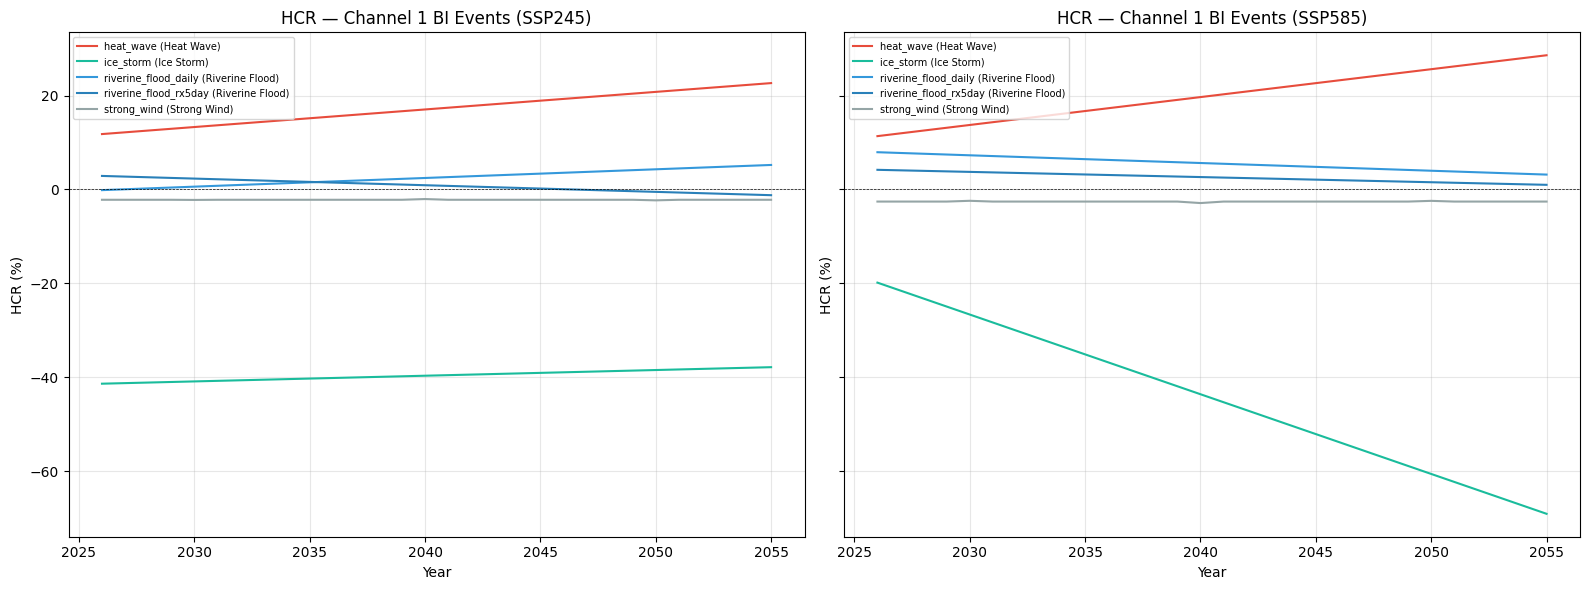

Saved: hcr_timeline.png


In [9]:
# ── Visualization: HCR Timeline ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

colors = {
    "heat_wave": "#e74c3c", "riverine_flood_daily": "#3498db",
    "riverine_flood_rx5day": "#2980b9", "strong_wind": "#95a5a6",
    "ice_storm": "#1abc9c",
}

for ax, ssp in zip(axes, SCENARIOS):
    for hazard in sorted(BI_HAZARDS):
        sub = hcr_annual_df[(hcr_annual_df["hazard"] == hazard) & (hcr_annual_df["scenario"] == ssp)]
        if not sub.empty:
            label = f"{hazard} ({HAZARD_CLASSIFICATION[hazard]['canonical_name']})"
            ax.plot(sub["year"], sub["hcr"] * 100, label=label,
                    color=colors.get(hazard, "gray"), linewidth=1.5)
    
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"HCR — Channel 1 BI Events ({ssp.upper()})")
    ax.set_xlabel("Year")
    ax.set_ylabel("HCR (%)")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(HCR_OUTPUT / "hcr_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hcr_timeline.png")

In [10]:
# ── Verification ─────────────────────────────────────────────────────────────

checks_passed = 0
checks_total = 0

def check(name, condition):
    global checks_passed, checks_total
    checks_total += 1
    status = "✓" if condition else "✗"
    if condition:
        checks_passed += 1
    print(f"  {status} {name}")

print("── HCR Checks ──")
hcr_read = pd.read_parquet(HCR_OUTPUT / "hcr_annual.parquet")
check("Parquet round-trips", len(hcr_read) == len(hcr_annual_df))
check("Has canonical_name column", "canonical_name" in hcr_read.columns)
check("Has computation column", "computation" in hcr_read.columns)

# Verify canonical names used
check("Uses 'riverine_flood_daily' (not extreme_precip)", "riverine_flood_daily" in hcr_read["hazard"].values)
check("Uses 'riverine_flood_rx5day' (not flood_rx5day)", "riverine_flood_rx5day" in hcr_read["hazard"].values)
check("Uses 'strong_wind' (not wind_extreme)", "strong_wind" in hcr_read["hazard"].values)
check("Uses 'ice_storm' (not icing_shutdown)", "ice_storm" in hcr_read["hazard"].values)
check("NO old name 'extreme_precip'", "extreme_precip" not in hcr_read["hazard"].values)
check("NO old name 'icing_shutdown'", "icing_shutdown" not in hcr_read["hazard"].values)

# Degradation hazards NOT in HCR output
check("freeze_thaw NOT in HCR", "freeze_thaw" not in hcr_read["hazard"].values)
check("frost_days NOT in HCR", "frost_days" not in hcr_read["hazard"].values)
check("wildfire NOT in HCR", "wildfire" not in hcr_read["hazard"].values)

# Sanity
hw = hcr_read[(hcr_read["hazard"] == "heat_wave") & (hcr_read["scenario"] == "ssp585")]
if not hw.empty:
    check("heat_wave HCR positive (SSP585)", hw["hcr"].mean() > 0)
    check("heat_wave HCR < 100%", hw["hcr"].mean() < 1.0)

ice = hcr_read[(hcr_read["hazard"] == "ice_storm") & (hcr_read["scenario"] == "ssp585")]
if not ice.empty:
    check("ice_storm HCR negative (warming benefit)", ice["hcr"].mean() < 0)

# JSON
hcr_j = json.load(open(HCR_OUTPUT / "hcr_results.json"))
check("JSON has severity_diagnostic", "severity_diagnostic" in hcr_j)
check("JSON has not_computable", "not_computable" in hcr_j)
check("JSON has risk_indicators", "risk_indicators" in hcr_j)
check("JSON has degradation_to_efr", "degradation_to_efr" in hcr_j)

# Intermediate counts
counts_read = pd.read_parquet(HCR_OUTPUT / "hazard_counts_intermediate.parquet")
check("Intermediate counts saved", len(counts_read) > 0)
check("freeze_thaw in intermediate (for NB04b)", "freeze_thaw" in counts_read["hazard"].values)

print(f"\n── Result: {checks_passed}/{checks_total} checks passed ──")
print(f"\nOutput files:")
for f in sorted(HCR_OUTPUT.glob("*")):
    print(f"  {f.name:45s} {f.stat().st_size:>8,} bytes")

── HCR Checks ──


  ✓ Parquet round-trips
  ✓ Has canonical_name column
  ✓ Has computation column
  ✓ Uses 'riverine_flood_daily' (not extreme_precip)
  ✓ Uses 'riverine_flood_rx5day' (not flood_rx5day)
  ✓ Uses 'strong_wind' (not wind_extreme)
  ✓ Uses 'ice_storm' (not icing_shutdown)
  ✓ NO old name 'extreme_precip'
  ✓ NO old name 'icing_shutdown'
  ✓ freeze_thaw NOT in HCR
  ✓ frost_days NOT in HCR
  ✓ wildfire NOT in HCR
  ✓ heat_wave HCR positive (SSP585)
  ✓ heat_wave HCR < 100%
  ✓ ice_storm HCR negative (warming benefit)
  ✓ JSON has severity_diagnostic
  ✓ JSON has not_computable
  ✓ JSON has risk_indicators
  ✓ JSON has degradation_to_efr
  ✓ Intermediate counts saved
  ✓ freeze_thaw in intermediate (for NB04b)

── Result: 21/21 checks passed ──

Output files:
  hazard_counts_intermediate.parquet              10,693 bytes
  hcr_annual.parquet                               9,091 bytes
  hcr_results.json                                 6,369 bytes
  hcr_timeline.png                            

## Summary

**What this notebook computed:**
- HCR (expected damage change ratio) for 5 BI hazards aligned with canonical names
- Severity diagnostic: mean excess above threshold (Phase 1)
- Risk indicators: direction + magnitude for wildfire and drought
- Documented gaps: hail, tornado, hurricane, coastal flood
- Intermediate counts: all 10 hazards saved for NB04b (EFR)

**What comes next:**
- NB04b: EFR (Peck's + Coffin-Manson + IUL) — reads intermediate counts
- Dashboard: add HCR + EFR tabs to Streamlit
- NB05: Financial integration (CFADS/NAV)